In [1]:
!python --version

Python 3.11.14


In [2]:
!echo $CONDA_DEFAULT_ENV

cellpose_env


## Monai wiht EfficientNet-B0/B3 (lightweight, great for cell morphology)

![BO](images/EfficientNet-Architecture-diagram.png)

<br>

![B3](images/Architecture-of-EfficientNet-B0-with-MBConv-as-Basic-building-blocks.png)


### EfficientNet is lighter, faster, and more accurate than DenseNet for microscopy.

| Model | Input Size | Parameters | Notes |
|-------|-------|-------|-------|
|B0 | 224×224 | 5.3M  | fast, small GPU |
| B3 | 300×300 | 12M | higher accuracy for cellular phenotypes |

In [3]:
!nvidia-smi

Fri Jan 23 11:07:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        Off |   00000000:01:00.0  On |                  N/A |
|  0%   58C    P8             34W /  350W |     462MiB /  24576MiB |     15%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
#!pip3 install opencv-python
#!pip3 instal monai tensorboard

In [5]:
import os, sys
import numpy as np
import pandas as pd

from glob import glob
from tqdm import tqdm

import matplotlib.pyplot as plt

sys.path.insert(1, '../src/')

from Basic import *
from image_lib import *
from neural_network_lib import *

In [6]:
import torch
torch.__version__

'2.9.1+cu128'

In [7]:
torch.cuda.is_available()

True

In [8]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3090'

In [9]:
import monai
monai.__version__

'1.5.1'

In [10]:
root0 = "../../colaboracoes/deOcesano/"
os.listdir(root0)

['samples', 'segment', 'crop', 'train_and_test', 'tables']

In [11]:
cp = Cellpose(root0=root0, verbose=True)

torch: 2.9.1+cu128

------- logger_setup() -----------
2026-01-23 11:07:19,272 [INFO] WRITING LOG OUTPUT TO /home/flavio/.cellpose/run.log
2026-01-23 11:07:19,272 [INFO] 
cellpose version: 	4.0.7 
platform:       	linux 
python version: 	3.11.14 
torch version:  	2.9.1+cu128
(<Logger cellpose.io (INFO)>, PosixPath('/home/flavio/.cellpose/run.log'))
2026-01-23 11:07:19,273 [INFO] ** TORCH CUDA version installed and working. **

------- GPU Ok -----------
>> current_device: 0
>> Device: NVIDIA GeForce RTX 3090
>> CUDA: 12.8 

>> torch.version.cuda: 12.8

Please set plate and experiment using create_roots(plate, experiment)



In [12]:
cp.set_default_parameters(root_yaml=os.getcwd(), verbose=True)

>> model_name   resnet18
>> crop_segment crop
>> dic_plate    5
>> ncrop    5


In [13]:
cp.root_samples, cp.root_crop

('../../colaboracoes/deOcesano/samples', '../../colaboracoes/deOcesano/crop')

In [14]:
plates = cp.list_plates(s_start='Plate')
plates

['Plate1896', 'Plate1848', 'Plate1895', 'Plate1849', 'Plate1847']

In [15]:
i=0
plate=plates[i]
print(">>> plate", plate)

cp.set_plate_params(plate=plate, verbose=True)

>>> plate Plate1896
>>> plate Plate1896 experiment must be set
	root_plate:	  '../../colaboracoes/deOcesano/samples/Plate1896'
	root_tbl_plate:  '../../colaboracoes/deOcesano/tables/Plate1896'
	root_crop_plate: '../../colaboracoes/deOcesano/crop/Plate1896'
	root_seg_plate:  '../../colaboracoes/deOcesano/segment/Plate1896'

	class_names 	 ['1pct', '1pct_il1b']
	probes 	 ['FACT', 'Faloidina', 'Rac1']
	dir_names 	 ['1perc', 'IL1B']
	dir_origins 	 []


In [16]:
cp.experiments

['Faloidina - 1%SFB and IL-1B',
 'Rac1 - 1%SFB and IL-1B',
 'Rac1 - 1%SFB',
 'Faloidina - 1%SFB',
 'FACT - 1%SFB and IL-1B',
 'FACT - 1%SFB']

In [17]:
cp.set_plate_params(plate=plate, verbose=False)

ncrop=5

for experiment in cp.experiments:
    cp.create_roots_experiment(experiment, verbose=False)
    fname_imgs = cp.list_crop_images_already_set(ncrop=ncrop, image_type='png', verbose=False)

    key = f"{plate} - {experiment}"
    print(key, len(fname_imgs), cp.root_crop_image)

Plate1896 - Faloidina - 1%SFB and IL-1B 1200 ../../colaboracoes/deOcesano/crop/Plate1896/Faloidina - 1%SFB and IL-1B
Plate1896 - Rac1 - 1%SFB and IL-1B 1200 ../../colaboracoes/deOcesano/crop/Plate1896/Rac1 - 1%SFB and IL-1B
Plate1896 - Rac1 - 1%SFB 1200 ../../colaboracoes/deOcesano/crop/Plate1896/Rac1 - 1%SFB
Plate1896 - Faloidina - 1%SFB 1200 ../../colaboracoes/deOcesano/crop/Plate1896/Faloidina - 1%SFB
Plate1896 - FACT - 1%SFB and IL-1B 1200 ../../colaboracoes/deOcesano/crop/Plate1896/FACT - 1%SFB and IL-1B
Plate1896 - FACT - 1%SFB 1200 ../../colaboracoes/deOcesano/crop/Plate1896/FACT - 1%SFB


In [18]:
filename = os.path.join(cp.root_crop_image, fname_imgs[0])
os.path.exists(filename), filename

(True,
 '../../colaboracoes/deOcesano/crop/Plate1896/FACT - 1%SFB/Overlay_D05_site_6.tif_crop_5_ncrop_5.png')

### Create dataset dictionary list

In [19]:
train_list, test_list, dft = cp.create_train_and_test_dataset(ncrop=5, perc_train=0.6, perc_test=0.4, sel_probes=[])
print(len(dft))
">>> plate_exp_dic", len(dft), len(test_list), len(train_list), ' - first item', train_list[0]

28


('>>> plate_exp_dic',
 28,
 16300,
 24450,
 ' - first item',
 {'img': '../../colaboracoes/deOcesano/crop/Plate1896/Faloidina - 1%SFB and IL-1B/Overlay_H07_site_2.tif_crop_5_ncrop_5.png',
  'label': 9})

In [20]:
len(cp.classes), cp.classes

(21,
 ['ATP5A1 - 1%SFB',
  'ATP5A1 - 1%SFB and IL-1B',
  'ATP5A1 - 10%SFB',
  'Bcatenin - 1%SFB',
  'Bcatenin - 1%SFB and IL-1B',
  'FACT - 1%SFB',
  'FACT - 1%SFB and IL-1B',
  'FACT - 10%SFB',
  'Faloidina - 1%SFB',
  'Faloidina - 1%SFB and IL-1B',
  'Faloidina - 10%SFB',
  'MMP1 - 1%SFB',
  'MMP1 - 1%SFB and IL-1B',
  'MMP1 - 10%SFB',
  'P21 - 1%SFB',
  'P21 - 1%SFB and IL-1B',
  'P21 - 10%SFB',
  'Rab9 - 1%SFB',
  'Rab9 - 1%SFB and IL-1B',
  'Rac1 - 1%SFB',
  'Rac1 - 1%SFB and IL-1B'])

In [21]:
len(cp.class_to_index), cp.class_to_index

(21,
 {'ATP5A1 - 1%SFB': 0,
  'ATP5A1 - 1%SFB and IL-1B': 1,
  'ATP5A1 - 10%SFB': 2,
  'Bcatenin - 1%SFB': 3,
  'Bcatenin - 1%SFB and IL-1B': 4,
  'FACT - 1%SFB': 5,
  'FACT - 1%SFB and IL-1B': 6,
  'FACT - 10%SFB': 7,
  'Faloidina - 1%SFB': 8,
  'Faloidina - 1%SFB and IL-1B': 9,
  'Faloidina - 10%SFB': 10,
  'MMP1 - 1%SFB': 11,
  'MMP1 - 1%SFB and IL-1B': 12,
  'MMP1 - 10%SFB': 13,
  'P21 - 1%SFB': 14,
  'P21 - 1%SFB and IL-1B': 15,
  'P21 - 10%SFB': 16,
  'Rab9 - 1%SFB': 17,
  'Rab9 - 1%SFB and IL-1B': 18,
  'Rac1 - 1%SFB': 19,
  'Rac1 - 1%SFB and IL-1B': 20})

In [22]:
filename = '../../colaboracoes/deOcesano/crop/Plate1848/FACT - 10%SFB/Overlay_B08_site_11.tif_crop_0_ncrop_5.png'
os.path.exists(filename)

True

In [23]:
print(len(dft))
dft.head(2)

28


,index,plate_exp,plate,experiment,probe,perturb,n,n_train,n_test,root
0,25,Plate1847 - ATP5A1 - 1%SFB,Plate1847,ATP5A1 - 1%SFB,ATP5A1,1%SFB,1200,720,480,../../colaboracoes/deOcesano/crop/Plate1847/AT...
1,24,Plate1847 - ATP5A1 - 1%SFB and IL-1B,Plate1847,ATP5A1 - 1%SFB and IL-1B,ATP5A1,1%SFB and IL-1B,1200,720,480,../../colaboracoes/deOcesano/crop/Plate1847/AT...


In [24]:
len(cp.classes)

21

In [25]:
train_list[:2]

[{'img': '../../colaboracoes/deOcesano/crop/Plate1896/Faloidina - 1%SFB and IL-1B/Overlay_H07_site_2.tif_crop_5_ncrop_5.png',
  'label': 9},
 {'img': '../../colaboracoes/deOcesano/crop/Plate1896/Faloidina - 1%SFB and IL-1B/Overlay_H07_site_5.tif_crop_1_ncrop_5.png',
  'label': 9}]

### CellDataset_b3: Transforms for B0 or B3 - EfficientNet-B3 (300×300)

### Dataset + Loader

### Build data

In [26]:
sel_probes = ['FACT', 'MMP1', 'Faloidina']
sel_probes = ['FACT']
sel_probes = ['Faloidina']
sel_probes = ['MMP1']
sel_probes = ['Rac1']

train_list, test_list, dft = cp.create_train_and_test_dataset(ncrop=5, perc_train=0.8, perc_test=0.2, sel_probes=sel_probes)
print(len(dft))
">>> plate_exp_dic", len(dft), len(train_list), ' - first item', train_list[0]

2


('>>> plate_exp_dic',
 2,
 1920,
 ' - first item',
 {'img': '../../colaboracoes/deOcesano/crop/Plate1896/Rac1 - 1%SFB and IL-1B/Overlay_H06_site_8.tif_crop_16_ncrop_5.png',
  'label': 1})

In [27]:
dft

,index,plate_exp,plate,experiment,probe,perturb,n,n_train,n_test,root
0,1,Plate1896 - Rac1 - 1%SFB,Plate1896,Rac1 - 1%SFB,Rac1,1%SFB,1200,960,240,../../colaboracoes/deOcesano/crop/Plate1896/Ra...
1,0,Plate1896 - Rac1 - 1%SFB and IL-1B,Plate1896,Rac1 - 1%SFB and IL-1B,Rac1,1%SFB and IL-1B,1200,960,240,../../colaboracoes/deOcesano/crop/Plate1896/Ra...


In [28]:
len(cp.classes), cp.classes

(2, ['Rac1 - 1%SFB', 'Rac1 - 1%SFB and IL-1B'])

In [29]:
cp.perc_train, cp.perc_test

(0.8, 0.2)

### Model (MONAI efficientnet-b3) – good for biomedical images

In [30]:
classes = cp.classes

mnn = MyNN(crop_or_segment='crop', ncrop=ncrop, sel_probes=sel_probes, 
           classes=classes, root0=root0, n_determinism=42, verbose=True)

>>> PyTorch version 2.9.1+cu128
>> current_device: 0
>> Device: NVIDIA GeForce RTX 3090
>> CUDA: 12.8
>>> There are 2 classes: Rac1 - 1%SFB_Rac1 - 1%SFB and IL-1B


In [31]:
lr=1e-4
weight_decay=1e-4
label_smoothing=0.1
pretrained=True

In [32]:
mnn.create_monai_EfficientNetBN_b3(lr=lr, weight_decay=weight_decay, 
                                   label_smoothing=label_smoothing, pretrained=pretrained)
# mnn.model, mnn.criterion, mnn.optimizer

### Loader

In [33]:
ds_train = mnn.CellDataset_b3(train_list)
ds_test = mnn.CellDataset_b3(test_list)

#-- set train_loader and test_loader
mnn.set_train_and_test_dataset(ds_train, ds_test, batch_size=16, shuffle=True, num_workers=4)   

In [34]:
len(mnn.train_loader), len(mnn.test_loader)

(120, 30)

In [35]:
filename, fname_model = mnn.get_model_name()
filename, fname_model

('../../colaboracoes/deOcesano/samples/cell_EfficientNet_B3_ncrop_5_probes_Rac1.pt',
 'cell_EfficientNet_B3_ncrop_5_probes_Rac1.pt')

In [36]:
#-- if found a mdel - reload train_loader and test_loader
ret, (model, train_losses, test_losses, accu_list) = mnn.read_model(verbose=True)
ret

Loading model with 21 epochs from '../../colaboracoes/deOcesano/samples/cell_EfficientNet_B3_ncrop_5_probes_Rac1.pt'
Reloading train and test dataloaders...


True

In [37]:
len(mnn.train_loader), len(mnn.test_loader)

(120, 30)

In [38]:
len(train_losses), train_losses[:5]

(21,
 [1.3356579800446828,
  0.8044013731181622,
  0.7499549450973669,
  0.6505536851783593,
  0.5906806056698163])

In [39]:
len(test_losses), test_losses[:5]

(21,
 [1.1115245987971625,
  0.9137940357128779,
  0.7786426554123561,
  0.8296941419442495,
  0.6430665443340937])

In [40]:
len(accu_list), accu_list[-5:]

(21,
 [0.9083333333333333,
  0.86875,
  0.9104166666666667,
  0.8916666666666667,
  0.9041666666666667])

### Use mixed precision (AMP)

AMP gives faster training + better stability:

In [41]:
len(mnn.train_losses), len(mnn.test_losses), len(mnn.accu_list)

(21, 21, 21)

In [50]:
n_epochs=15
verbose=True

mnn.train_monai_model(n_epochs=n_epochs, n_max_repeat=5, verbose=verbose)

Epoch 1/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:10<00:00, 11.87it/s]


Epoch 1 - accuracy: 93.3% loss train: 0.2245 test: 0.3199


Epoch 2/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:09<00:00, 12.14it/s]


Epoch 2 - accuracy: 91.5% loss train: 0.2220 test: 0.3334


Epoch 3/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:10<00:00, 11.87it/s]


Epoch 3 - accuracy: 93.3% loss train: 0.2189 test: 0.3208


Epoch 4/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:10<00:00, 11.86it/s]


Epoch 4 - accuracy: 93.1% loss train: 0.2474 test: 0.3405


Epoch 5/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 120/120 [00:10<00:00, 11.62it/s]


File saved at '../../colaboracoes/deOcesano/samples/cell_EfficientNet_B3_ncrop_5_probes_Rac1.pt'
-------- training complete ----------


In [51]:
len(mnn.accu_list), np.round( [np.max(mnn.accu_list)*100, 100*mnn.maxi] ,1)

(44, array([93.5, 93.5]))

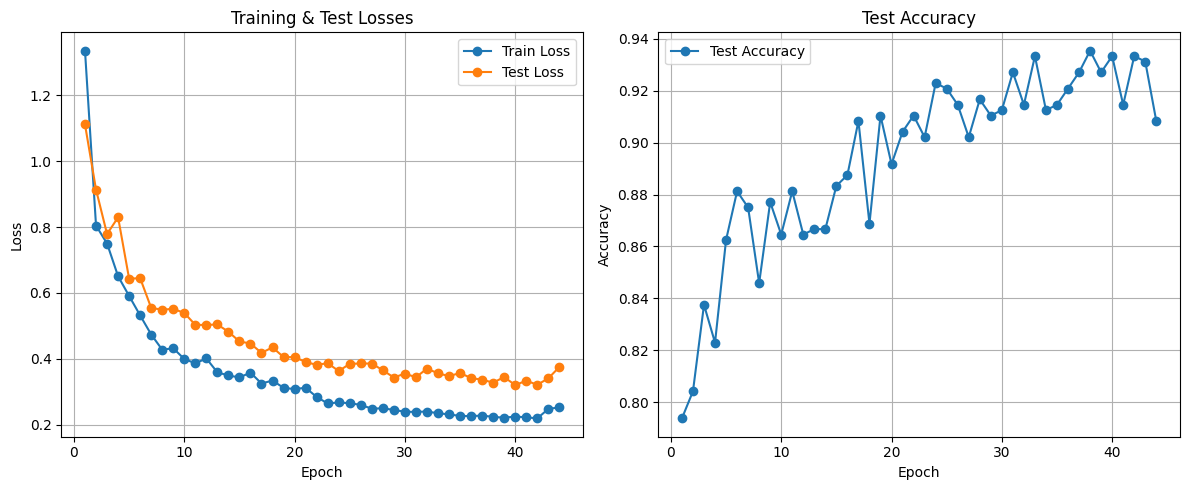

In [52]:
mnn.plot_losses_and_accuracy(figsize=(12,5))

In [46]:
len(mnn.train_losses)

29

In [47]:
len(mnn.train_loader), len(mnn.test_loader)

(120, 30)